# NAR CE Dataset Exploration

This notebook provides tools to load and explore NAR (No Audio-Raw) Complex Event datasets.

NAR datasets contain:
- **Data**: Ground-truth Atomic Event (AE) labels per time window
- **Labels**: Complex Event (CE) labels per time window

These datasets are useful for testing CE detection models with perfect AE predictions.

### Generate with Custom Window Size

Modify `WINDOW_SIZE` in the cell above, then run the cell below.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import os

# Configuration
WINDOW_SIZE = 2.0  # Window size in seconds (2.5 for default, 2.0 for 2s windows, etc.)

# Automatically set directory based on window size
if WINDOW_SIZE == 2.5:
    NAR_DATA_DIR = 'CE_dataset/nar/'
else:
    NAR_DATA_DIR = f'CE_dataset/nar_w{WINDOW_SIZE}s/'

DATASET_CONFIG_FILE = 'Multimodal/dataset_config_w2.5.json'

sns.set_style('whitegrid')
%matplotlib inline

print(f"Configuration:")
print(f"  Window size: {WINDOW_SIZE}s")
print(f"  NAR data directory: {NAR_DATA_DIR}")
print("\nImports loaded successfully!")

Configuration:
  Window size: 2.0s
  NAR data directory: CE_dataset/nar_w2.0s/

Imports loaded successfully!


### Generate with Custom Window Size (Post-Processing)

For window sizes other than 2.5s, use realistic windowing to post-process existing NAR data.

**Note**: Now using the unified `realistic_windowing.py` tool with `--dataset-type nar` flag.

In [3]:
# Generate NAR datasets with custom window size via realistic windowing
# This post-processes existing 2.5s NAR data to any detection window W
# Uses WINDOW_SIZE and NAR_DATA_DIR from the configuration above

# Training set
!python realistic_windowing.py --dataset-type nar --input-dir CE_dataset/nar --detection-window {WINDOW_SIZE} --output-dir {NAR_DATA_DIR} --split train --n-samples 80000

# # Validation set
# !python realistic_windowing.py --dataset-type nar --input-dir CE_dataset/nar --detection-window {WINDOW_SIZE} --output-dir {NAR_DATA_DIR} --split val

# # Test set
# !python realistic_windowing.py --dataset-type nar --input-dir CE_dataset/nar --detection-window {WINDOW_SIZE} --output-dir {NAR_DATA_DIR} --split test
# !python realistic_windowing.py --dataset-type nar --input-dir CE_dataset/nar --detection-window {WINDOW_SIZE} --output-dir {NAR_DATA_DIR} --split test --duration 15
# !python realistic_windowing.py --dataset-type nar --input-dir CE_dataset/nar --detection-window {WINDOW_SIZE} --output-dir {NAR_DATA_DIR} --split test --duration 30


REALISTIC WINDOWING - NAR DATASET
Dataset type:     NAR (symbolic labels only)
Input directory:  CE_dataset/nar
Output directory: CE_dataset/nar_w2.0s
Detection window: 2.0s
Split:            train
N samples:        80000


REALISTIC DETECTION WINDOW PROCESSING (NAR)
Input file: CE_dataset/nar/ct_ce5min_train_data_80000.npy
Detection window size: 2.0s
Delta granularity: 0.5s

[1/4] Loading NAR data...
Loaded 80000 samples with 120 windows each

[2/4] Subdividing AE labels to fine-grained deltas...
Subdivided 120 windows (2.5s each) into 600 deltas (0.5s each)
  Deltas per window: 5

[3/4] Aggregating AE labels with majority voting...
Aggregated 600 deltas (0.5s each) into 150 detection windows (2.0s each)
  Deltas per detection window: 4

[4/4] Re-computing CE labels with FSMs...

Re-computing CE labels for 80000 samples with 150 windows each...
  Processed 100/80000 samples
  Processed 200/80000 samples
  Processed 300/80000 samples
  Processed 400/80000 samples
  Processed 500/80000

## 3. List Generated Files

In [7]:
# List available NAR datasets from all directories
print("Generated NAR Dataset Files:")
print("=" * 70)

# Find all NAR-related directories
base_dir = Path('CE_dataset')
nar_dirs = []

# Add default NAR directory
if (base_dir / 'nar').exists():
    nar_dirs.append(('nar (W=2.5s)', base_dir / 'nar'))

# Add custom window size directories
for dir_path in sorted(base_dir.glob('nar_w*')):
    if dir_path.is_dir():
        dir_name = dir_path.name
        window_size = dir_name.replace('nar_w', '').replace('s', '')
        nar_dirs.append((f'{dir_name} (W={window_size}s)', dir_path))

if not nar_dirs:
    print("  No NAR directories found.")
else:
    for dir_label, dir_path in nar_dirs:
        print(f"\n{dir_label}:")
        files = sorted(dir_path.glob('*.npy'))
        if files:
            for f in files:
                size_kb = os.path.getsize(f) / 1024
                if size_kb < 1024:
                    print(f'  {f.name:50s}: {size_kb:8.1f} KB')
                else:
                    print(f'  {f.name:50s}: {size_kb/1024:8.2f} MB')
        else:
            print("  No .npy files found")

print("\n" + "=" * 70)

Generated NAR Dataset Files:

nar (W=2.5s):
  ct_ce5min_test_data.npy                           :     4.58 MB
  ct_ce5min_test_labels.npy                         :     5.72 MB
  ct_ce5min_train_data_40000.npy                    :    36.62 MB
  ct_ce5min_train_labels_40000.npy                  :    45.78 MB
  ct_ce5min_val_data.npy                            :     4.58 MB
  ct_ce5min_val_labels.npy                          :     5.72 MB

nar_w2.0s (W=2.0s):
  No .npy files found



## 4. Configuration and Label Mappings

In [3]:
# Load label mappings
with open(DATASET_CONFIG_FILE, 'r') as f:
    config = json.load(f)

# AE label mapping (0-8)
ae_label_mapping = config['label_mapping']
ae_labels_inv = {v: k for k, v in ae_label_mapping.items()}

# CE label mapping (0-10)
ce_labels_names = {
    0: 'No violation',
    1: 'Event 1: Post-toilet handwashing',
    2: 'Event 2: Pre-meal handwashing',
    3: 'Event 3: Insufficient brushing (<120s)',
    4: 'Event 4: Post-meal routine',
    5: 'Event 5: Work session pattern',
    6: 'Event 6: Adequate handwashing (30s)',
    7: 'Event 7: Adequate brushing (≥120s)',
    8: 'Event 8: Post-meal rest (180s)',
    9: 'Event 9: Active typing (3 sessions)',
    10: 'Event 10: Focused work (5 clicks)'
}

print("AE Label Mapping (Atomic Activities):")
for name, label in ae_label_mapping.items():
    print(f"  {name:20s}: {label}")

print("\nCE Label Mapping (Complex Events):")
for label, name in ce_labels_names.items():
    print(f"  {label:2d}: {name}")

AE Label Mapping (Atomic Activities):
  brush_teeth         : 0
  click_mouse         : 1
  drink               : 2
  eat                 : 3
  flush_toilet        : 4
  sit                 : 5
  type                : 6
  walk                : 7
  wash                : 8

CE Label Mapping (Complex Events):
   0: No violation
   1: Event 1: Post-toilet handwashing
   2: Event 2: Pre-meal handwashing
   3: Event 3: Insufficient brushing (<120s)
   4: Event 4: Post-meal routine
   5: Event 5: Work session pattern
   6: Event 6: Adequate handwashing (30s)
   7: Event 7: Adequate brushing (≥120s)
   8: Event 8: Post-meal rest (180s)
   9: Event 9: Active typing (3 sessions)
  10: Event 10: Focused work (5 clicks)


## 5. Load NAR Dataset

Modify the parameters below to load different NAR datasets.

In [4]:
def load_nar_dataset(duration=5, split='train', n_samples=None):
    """
    Load NAR dataset.
    
    Args:
        duration: CE duration in minutes (3, 5, 15, or 30)
        split: Dataset split ('train', 'val', or 'test')
        n_samples: Number of samples (None to auto-detect)
    
    Returns:
        tuple: (ae_labels, ce_labels, info)
    """
    data_dir = Path(NAR_DATA_DIR)
    
    # Find matching files
    if n_samples is not None:
        data_file = data_dir / f'ct_ce{duration}min_{split}_data_{n_samples}.npy'
        labels_file = data_dir / f'ct_ce{duration}min_{split}_labels_{n_samples}.npy'
    else:
        # Auto-detect
        pattern = f'ct_ce{duration}min_{split}_data_*.npy'
        matches = list(data_dir.glob(pattern))
        if not matches:
            raise FileNotFoundError(f"No NAR dataset found for duration={duration}, split={split}")
        data_file = matches[0]
        labels_file = data_file.parent / data_file.name.replace('_data_', '_labels_')
    
    if not data_file.exists():
        raise FileNotFoundError(f"Data file not found: {data_file}")
    if not labels_file.exists():
        raise FileNotFoundError(f"Labels file not found: {labels_file}")
    
    # Load data
    ae_labels = np.load(data_file)
    ce_labels = np.load(labels_file)
    
    info = {
        'duration': duration,
        'split': split,
        'n_samples': ae_labels.shape[0],
        'n_windows': ae_labels.shape[1],
        'data_file': str(data_file),
        'labels_file': str(labels_file)
    }
    
    return ae_labels, ce_labels, info


# Load a dataset (modify parameters as needed)
duration = 5
split = 'train'
n_samples = 40000  # Set to None to auto-detect

ae_data, ce_labels, info = load_nar_dataset(duration=duration, split=split, n_samples=n_samples)

print("Dataset Info:")
for key, value in info.items():
    print(f"  {key:15s}: {value}")

print(f"\nAE Data Shape:  {ae_data.shape}  (samples, windows)")
print(f"CE Labels Shape: {ce_labels.shape}  (samples, windows, labels)")

Dataset Info:
  duration       : 5
  split          : train
  n_samples      : 40000
  n_windows      : 120
  data_file      : CE_dataset/nar/ct_ce5min_train_data_40000.npy
  labels_file    : CE_dataset/nar/ct_ce5min_train_labels_40000.npy

AE Data Shape:  (40000, 120)  (samples, windows)
CE Labels Shape: (40000, 120, 10)  (samples, windows, labels)


## 6. View Sample Data

In [4]:
# View first few samples
sample_idx = 0
n_windows_to_show = 10

print(f"Sample {sample_idx}:")
print("\nFirst {n_windows_to_show} windows:")
print(f"  AE Labels (data):  {ae_data[sample_idx, :n_windows_to_show]}")
print(f"  CE Labels:         {ce_labels[sample_idx, :n_windows_to_show]}")

# Decode AE labels
print("\nDecoded AE Sequence:")
ae_sequence = ae_data[sample_idx, :n_windows_to_show]
for i, label in enumerate(ae_sequence):
    print(f"  Window {i:2d}: {ae_labels_inv[label]:15s} (label {label})")

Sample 0:

First {n_windows_to_show} windows:
  AE Labels (data):  [7 7 7 7 7 5 5 5 5 7]
  CE Labels:         [[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]

Decoded AE Sequence:
  Window  0: walk            (label 7)
  Window  1: walk            (label 7)
  Window  2: walk            (label 7)
  Window  3: walk            (label 7)
  Window  4: walk            (label 7)
  Window  5: sit             (label 5)
  Window  6: sit             (label 5)
  Window  7: sit             (label 5)
  Window  8: sit             (label 5)
  Window  9: walk            (label 7)


## 7. Dataset Statistics

In [5]:
def print_dataset_statistics(ae_data, ce_labels):
    """
    Print comprehensive dataset statistics for multi-label CE format.
    """
    print("=" * 70)
    print("Dataset Statistics")
    print("=" * 70)
    
    # AE label distribution
    print("\nAtomic Event Label Distribution:")
    unique_ae, counts_ae = np.unique(ae_data, return_counts=True)
    total_windows = ae_data.size
    for label, count in zip(unique_ae, counts_ae):
        ae_name = ae_labels_inv[label]
        print(f"  {label}: {ae_name:20s} - {count:6d} windows ({count/total_windows*100:5.2f}%)")
    
    # CE label distribution (multi-label format: n_samples x n_windows x 10)
    print("\nComplex Event Label Distribution (per event):")
    for event_idx in range(10):
        event_id = event_idx + 1  # Events are 1-10
        event_active = ce_labels[:, :, event_idx]  # All samples, all windows, this event
        count = np.sum(event_active)
        ce_name = ce_labels_names[event_id]
        print(f"  Event {event_id:2d}: {count:6d} windows ({count/total_windows*100:5.2f}%) - {ce_name}")
    
    # Count windows with no events (all zeros across event dimension)
    no_event_windows = np.sum(np.sum(ce_labels, axis=2) == 0)
    print(f"  No events: {no_event_windows:6d} windows ({no_event_windows/total_windows*100:5.2f}%)")
    
    # Multi-label statistics
    print("\n" + "-"*70)
    print("Multi-Label Analysis")
    print("-"*70)
    
    events_per_window = np.sum(ce_labels, axis=2)  # (n_samples, n_windows)
    
    print(f"\nEvents per window:")
    print(f"  Mean:   {events_per_window.mean():.3f}")
    print(f"  Median: {np.median(events_per_window):.1f}")
    print(f"  Max:    {int(events_per_window.max())}")
    
    # Distribution of simultaneous events
    print(f"\nDistribution of simultaneous events per window:")
    unique_counts, count_freqs = np.unique(events_per_window, return_counts=True)
    for n_events, freq in zip(unique_counts, count_freqs):
        print(f"  {int(n_events)} events: {freq:6d} windows ({freq/total_windows*100:5.2f}%)")
    
    # Sample-level statistics
    print(f"\n" + "-"*70)
    print("Sample-Level Statistics")
    print("-"*70)
    
    # Check if each sample has at least one event
    has_any_event = np.any(events_per_window > 0, axis=1)
    samples_with_events = np.sum(has_any_event)
    n_samples = ce_labels.shape[0]
    samples_without_events = n_samples - samples_with_events
    
    print(f"\nSamples by event presence:")
    print(f"  Samples with 0 events:      {samples_without_events:6d} ({samples_without_events/n_samples*100:5.2f}%)")
    print(f"  Samples with ≥1 event:      {samples_with_events:6d} ({samples_with_events/n_samples*100:5.2f}%)")
    
    # Total event occurrences per sample
    total_events_per_sample = np.sum(events_per_window, axis=1)
    print(f"\nTotal event occurrences per sample:")
    print(f"  Mean:   {total_events_per_sample.mean():.2f} windows")
    print(f"  Median: {np.median(total_events_per_sample):.0f} windows")
    print(f"  Min:    {int(total_events_per_sample.min())} windows")
    print(f"  Max:    {int(total_events_per_sample.max())} windows")


print_dataset_statistics(ae_data, ce_labels)

Dataset Statistics

Atomic Event Label Distribution:
  0: brush_teeth          - 534141 windows (11.13%)
  1: click_mouse          - 144522 windows ( 3.01%)
  2: drink                -  87167 windows ( 1.82%)
  3: eat                  - 129656 windows ( 2.70%)
  4: flush_toilet         -  37972 windows ( 0.79%)
  5: sit                  - 1716157 windows (35.75%)
  6: type                 - 279450 windows ( 5.82%)
  7: walk                 - 1481923 windows (30.87%)
  8: wash                 - 389012 windows ( 8.10%)

Complex Event Label Distribution (per event):
  Event  1:   6470 windows ( 0.13%) - Event 1: Post-toilet handwashing
  Event  2:  13084 windows ( 0.27%) - Event 2: Pre-meal handwashing
  Event  3:   8203 windows ( 0.17%) - Event 3: Insufficient brushing (<120s)
  Event  4:   4681 windows ( 0.10%) - Event 4: Post-meal routine
  Event  5:   5962 windows ( 0.12%) - Event 5: Work session pattern
  Event  6:   4874 windows ( 0.10%) - Event 6: Adequate handwashing (30s)
  Event

## 8. Visualize Label Distributions

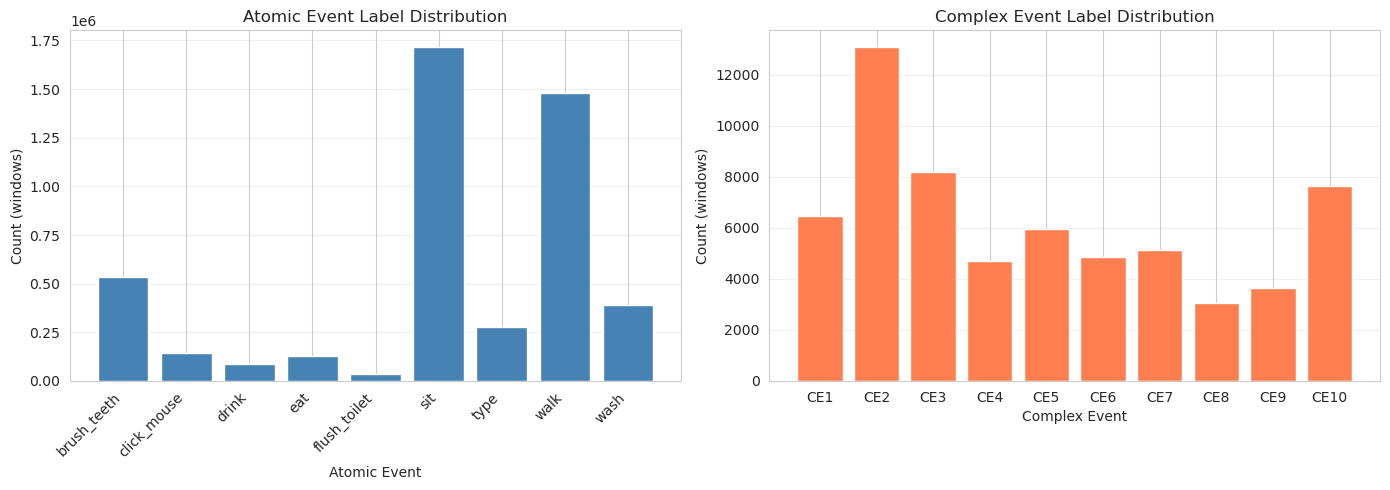


CE Event Percentages:
  Event  1:   6470 windows ( 0.13%)
  Event  2:  13084 windows ( 0.27%)
  Event  3:   8203 windows ( 0.17%)
  Event  4:   4681 windows ( 0.10%)
  Event  5:   5962 windows ( 0.12%)
  Event  6:   4874 windows ( 0.10%)
  Event  7:   5131 windows ( 0.11%)
  Event  8:   3066 windows ( 0.06%)
  Event  9:   3627 windows ( 0.08%)
  Event 10:   7654 windows ( 0.16%)


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AE label distribution
unique_ae, counts_ae = np.unique(ae_data, return_counts=True)
ae_names = [ae_labels_inv[label] for label in unique_ae]
axes[0].bar(range(len(unique_ae)), counts_ae, color='steelblue')
axes[0].set_xticks(range(len(unique_ae)))
axes[0].set_xticklabels(ae_names, rotation=45, ha='right')
axes[0].set_xlabel('Atomic Event')
axes[0].set_ylabel('Count (windows)')
axes[0].set_title('Atomic Event Label Distribution')
axes[0].grid(axis='y', alpha=0.3)

# CE label distribution (multi-label format: count per event)
total_windows = ae_data.size
event_counts = np.sum(ce_labels, axis=(0, 1))  # Sum over samples and windows
event_ids = np.arange(1, 11)
event_names_short = [f"CE{i}" for i in event_ids]

axes[1].bar(range(len(event_counts)), event_counts, color='coral')
axes[1].set_xticks(range(len(event_counts)))
axes[1].set_xticklabels(event_names_short)
axes[1].set_xlabel('Complex Event')
axes[1].set_ylabel('Count (windows)')
axes[1].set_title('Complex Event Label Distribution')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print percentages
print("\nCE Event Percentages:")
for i, (event_id, count) in enumerate(zip(event_ids, event_counts)):
    pct = count / total_windows * 100
    print(f"  Event {event_id:2d}: {count:6d} windows ({pct:5.2f}%)")

## 9. Visualize Sample Sequences

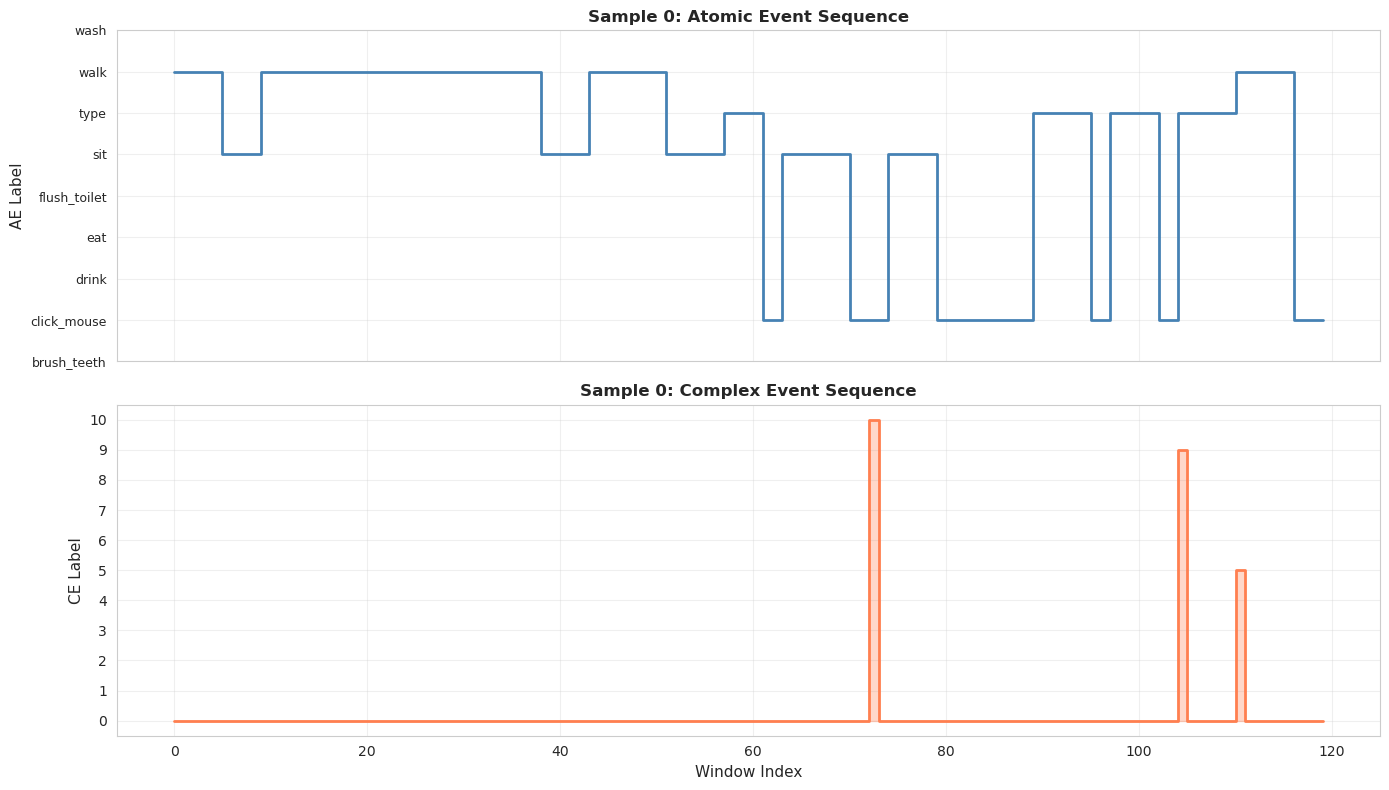


CE Events detected in sample 0:
  Event 5: Event 5: Work session pattern
    Active at windows: [110]
  Event 9: Event 9: Active typing (3 sessions)
    Active at windows: [104]
  Event 10: Event 10: Focused work (5 clicks)
    Active at windows: [72]


In [44]:
def visualize_sample(ae_data, ce_labels, sample_idx, window_range=None):
    """
    Visualize AE and CE label sequences for a sample (multi-label format).
    
    Args:
        ae_data: AE labels array (n_samples, n_windows)
        ce_labels: CE labels array (n_samples, n_windows, 10)
        sample_idx: Sample index to visualize
        window_range: Tuple (start, end) to show subset of windows, or None for all
    """
    if window_range is None:
        start, end = 0, ae_data.shape[1]
    else:
        start, end = window_range
    
    ae_seq = ae_data[sample_idx, start:end]
    ce_seq = ce_labels[sample_idx, start:end, :]  # (n_windows, 10)
    windows = np.arange(start, end)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Plot AE labels
    axes[0].step(windows, ae_seq, where='post', linewidth=2, color='steelblue')
    axes[0].set_ylabel('AE Label', fontsize=11)
    axes[0].set_title(f'Sample {sample_idx}: Atomic Event Sequence', fontsize=12, fontweight='bold')
    axes[0].set_yticks(range(9))
    axes[0].set_yticklabels([ae_labels_inv[i] for i in range(9)], fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # Plot CE labels (multi-label: show primary event with shading for overlaps)
    # For display, show the maximum event ID at each window
    ce_max = np.zeros(len(ce_seq))
    for i in range(len(ce_seq)):
        active = np.where(ce_seq[i] == 1)[0]
        if len(active) > 0:
            ce_max[i] = active[-1] + 1  # Show highest event ID (convert to 1-indexed)
        else:
            ce_max[i] = 0
    
    # Plot stepped line with filling
    axes[1].step(windows, ce_max, where='post', linewidth=2, color='coral')
    axes[1].fill_between(windows, 0, ce_max, step='post', color='coral', alpha=0.3)
    
    # Highlight multi-label windows with additional shading
    events_per_window = np.sum(ce_seq, axis=1)
    multilabel_windows = np.where(events_per_window > 1)[0]
    for w in multilabel_windows:
        axes[1].axvspan(windows[w], windows[w] + 1, color='yellow', alpha=0.4, zorder=5)
    
    axes[1].set_xlabel('Window Index', fontsize=11)
    axes[1].set_ylabel('CE Label', fontsize=11)
    axes[1].set_title(f'Sample {sample_idx}: Complex Event Sequence', fontsize=12, fontweight='bold')
    axes[1].set_yticks(range(0, 11))
    axes[1].set_ylim(-0.5, 10.5)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print CE violations found
    active_events = np.where(np.any(ce_seq, axis=0))[0] + 1
    
    if len(active_events) > 0:
        print(f"\nCE Events detected in sample {sample_idx}:")
        for event_id in active_events:
            event_idx = event_id - 1
            windows_with_event = np.where(ce_seq[:, event_idx] == 1)[0] + start
            print(f"  Event {event_id}: {ce_labels_names[event_id]}")
            print(f"    Active at windows: {windows_with_event.tolist()}")
        
        # Check for multi-label windows
        if len(multilabel_windows) > 0:
            multilabel_windows_adj = multilabel_windows + start
            print(f"\n  Multi-label windows (>1 event, yellow shading): {multilabel_windows_adj.tolist()}")
            for w in multilabel_windows:
                active_at_w = np.where(ce_seq[w, :] == 1)[0] + 1
                print(f"    Window {w + start}: Events {active_at_w.tolist()}")
    else:
        print(f"\nNo CE violations in sample {sample_idx}")


# Visualize a sample
sample_idx = 0
visualize_sample(ae_data, ce_labels, sample_idx)

## 10. Find Specific Patterns

Samples with Event 1: Post-toilet handwashing:
  Found 6470 samples
  Sample indices: [4, 5, 6, 7, 9, 10, 11, 14, 15, 16]...

Visualizing sample 4:


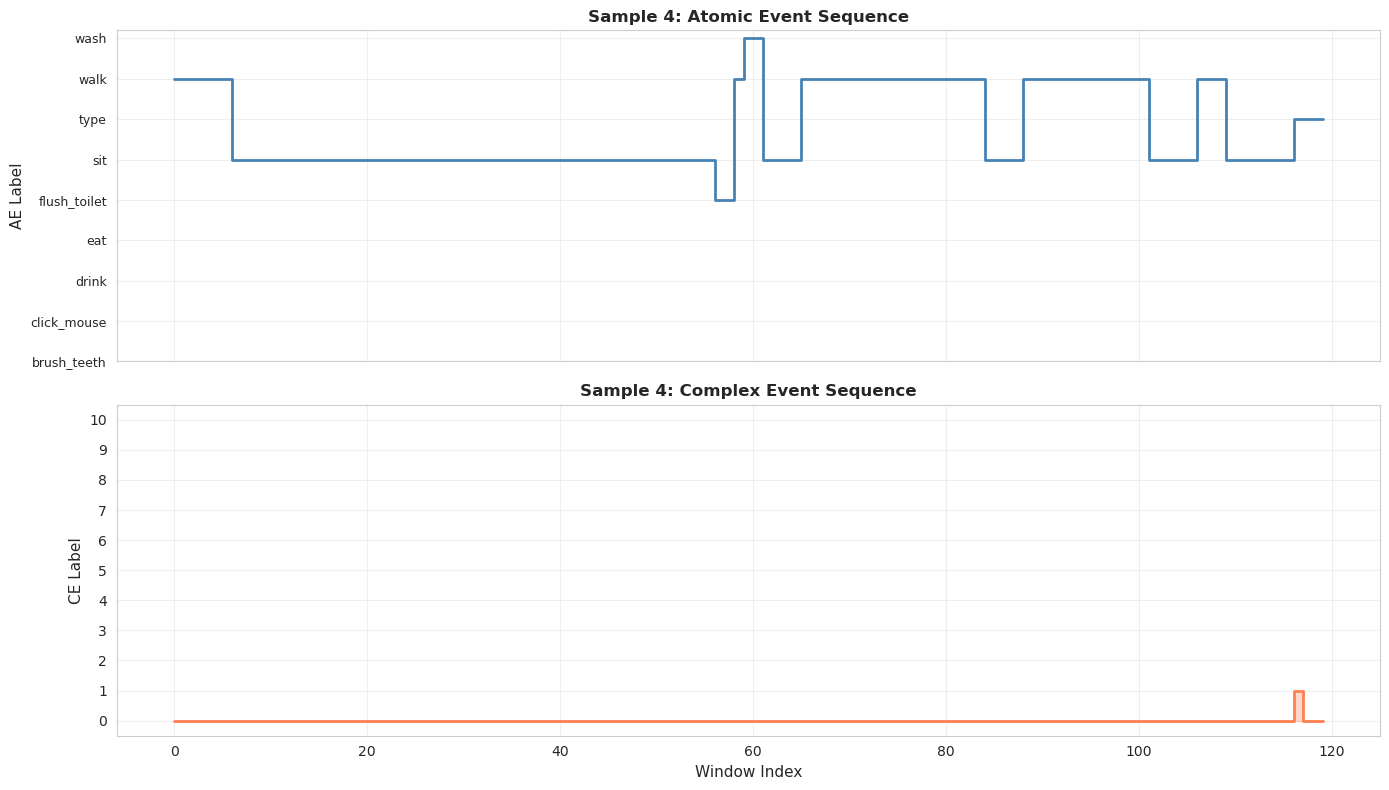


CE Events detected in sample 4:
  Event 1: Event 1: Post-toilet handwashing
    Active at windows: [116]


In [45]:
def find_samples_with_ce(ce_labels, ce_type):
    """
    Find all samples containing a specific CE violation (multi-label format).
    
    Args:
        ce_labels: CE labels array (n_samples, n_windows, 10)
        ce_type: CE event ID to search for (1-10)
    
    Returns:
        Array of sample indices
    """
    event_idx = ce_type - 1  # Convert event ID to array index
    samples = np.where(np.any(ce_labels[:, :, event_idx] == 1, axis=1))[0]
    return samples


# Find samples with a specific CE violation
ce_type = 1  # Event 1: Post-toilet handwashing
samples = find_samples_with_ce(ce_labels, ce_type)

print(f"Samples with {ce_labels_names[ce_type]}:")
print(f"  Found {len(samples)} samples")
if len(samples) > 0:
    print(f"  Sample indices: {samples[:10].tolist()}{'...' if len(samples) > 10 else ''}")
    
    # Visualize first sample with this violation
    sample_idx = samples[0]
    print(f"\nVisualizing sample {sample_idx}:")
    visualize_sample(ae_data, ce_labels, sample_idx)
else:
    print("  No samples found with this event")

## 11. Interactive Sample Browser

Sample 5 / 39999

Full AE Sequence (first 30 windows):
  Windows  0- 9: walk -> walk -> walk -> walk -> walk -> sit -> sit -> sit -> sit -> sit
  Windows 10-19: sit -> sit -> sit -> sit -> sit -> sit -> sit -> sit -> sit -> sit
  Windows 20-29: flush_toilet -> flush_toilet -> flush_toilet -> flush_toilet -> walk -> wash -> wash -> wash -> sit -> sit

CE Violations: 1 types
  CE1: Event 1: Post-toilet handwashing
       Windows: [80]


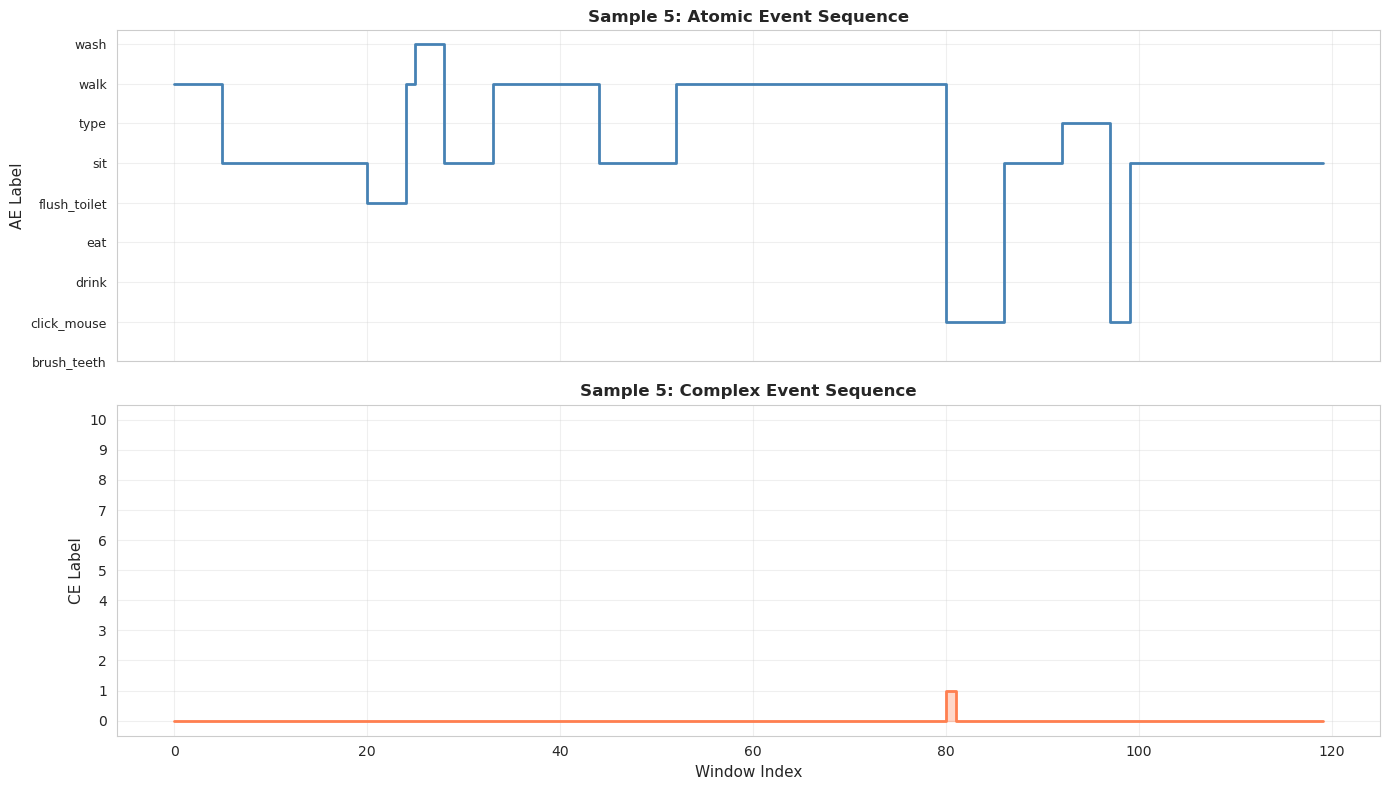


CE Events detected in sample 5:
  Event 1: Event 1: Post-toilet handwashing
    Active at windows: [80]


In [46]:
# Simple interactive browser
# Change sample_idx to explore different samples

sample_idx = 5  # Change this to view different samples

print(f"=" * 70)
print(f"Sample {sample_idx} / {ae_data.shape[0]-1}")
print(f"=" * 70)

# Print sequence
print("\nFull AE Sequence (first 30 windows):")
ae_seq = ae_data[sample_idx, :30]
ae_names_seq = [ae_labels_inv[label] for label in ae_seq]
for i in range(0, len(ae_names_seq), 10):
    print(f"  Windows {i:2d}-{i+9:2d}: {' -> '.join(ae_names_seq[i:i+10])}")

# CE violations
ce_seq = ce_labels[sample_idx]
violations = np.unique(ce_seq[ce_seq != 0])
print(f"\nCE Violations: {len(violations)} types")
for v in violations:
    windows_with_v = np.where(ce_seq == v)[0]
    print(f"  CE{v}: {ce_labels_names[v]}")
    print(f"       Windows: {windows_with_v.tolist()}")

# Visualize
visualize_sample(ae_data, ce_labels, sample_idx)

Sample 5 / 39999

Full AE Sequence (first 30 windows):
  Windows  0- 9: walk -> walk -> walk -> walk -> walk -> sit -> sit -> sit -> sit -> sit
  Windows 10-19: sit -> sit -> sit -> sit -> sit -> sit -> sit -> sit -> sit -> sit
  Windows 20-29: flush_toilet -> flush_toilet -> flush_toilet -> flush_toilet -> walk -> wash -> wash -> wash -> sit -> sit

CE Violations: 1 event types active
  Event 1: Event 1: Post-toilet handwashing
            Windows: [80]


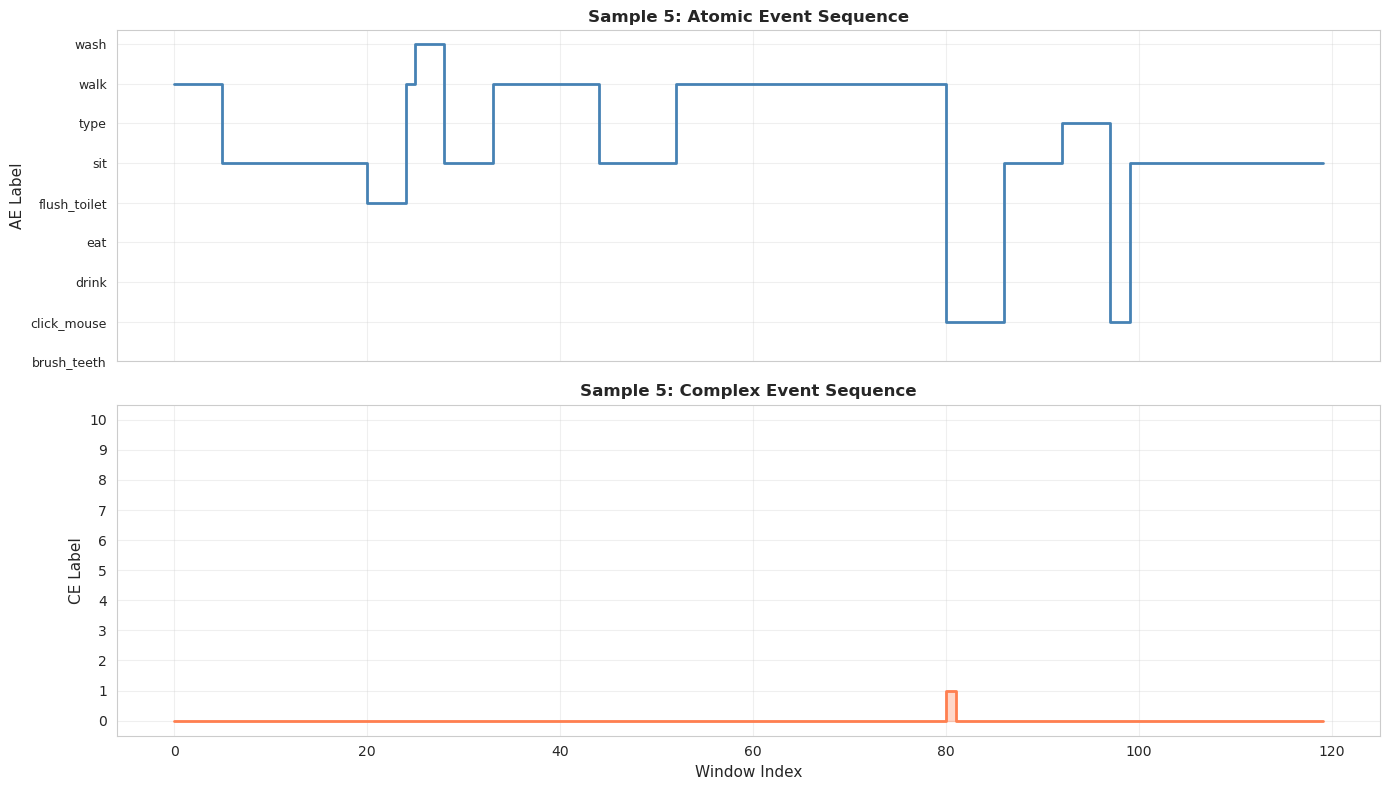


CE Events detected in sample 5:
  Event 1: Event 1: Post-toilet handwashing
    Active at windows: [80]


In [47]:
# Simple interactive browser
# Change sample_idx to explore different samples

sample_idx = 5  # Change this to view different samples

print(f"=" * 70)
print(f"Sample {sample_idx} / {ae_data.shape[0]-1}")
print(f"=" * 70)

# Print sequence
print("\nFull AE Sequence (first 30 windows):")
ae_seq = ae_data[sample_idx, :30]
ae_names_seq = [ae_labels_inv[label] for label in ae_seq]
for i in range(0, len(ae_names_seq), 10):
    print(f"  Windows {i:2d}-{i+9:2d}: {' -> '.join(ae_names_seq[i:i+10])}")

# CE violations (multi-label format)
ce_seq = ce_labels[sample_idx]  # Shape: (n_windows, 10)
events_per_window = np.sum(ce_seq, axis=1)  # (n_windows,)
active_events = np.where(np.any(ce_seq, axis=0))[0] + 1  # Event IDs (1-10)

print(f"\nCE Violations: {len(active_events)} event types active")
if len(active_events) > 0:
    for event_id in active_events:
        event_idx = event_id - 1
        windows_with_event = np.where(ce_seq[:, event_idx] == 1)[0]
        print(f"  Event {event_id}: {ce_labels_names[event_id]}")
        print(f"            Windows: {windows_with_event.tolist()}")
    
    # Check for multi-label windows
    multilabel_windows = np.where(events_per_window > 1)[0]
    if len(multilabel_windows) > 0:
        print(f"\n  Multi-label windows ({len(multilabel_windows)} windows with >1 event):")
        for w in multilabel_windows[:5]:  # Show first 5
            active_at_w = np.where(ce_seq[w, :] == 1)[0] + 1
            print(f"    Window {w}: Events {active_at_w.tolist()}")
        if len(multilabel_windows) > 5:
            print(f"    ... and {len(multilabel_windows) - 5} more")
else:
    print("  No CE violations in this sample")

# Visualize
visualize_sample(ae_data, ce_labels, sample_idx)